In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# The Transformer Block

The previous chapter built attention: a layer that lets every position read
from every other, weighted by learned relevance. Attention alone, however, is
not what anyone deploys. Deployed models stack a composite unit — the
*transformer block* — in which attention supplies communication between
positions and a position-wise feed-forward network supplies computation
within each one, both writing their results into a shared residual stream.
This section builds that unit. We settle the two design decisions that
separate a 2017 block from a 2026 one: where the normalization layers go
(with an experiment at initialization that shows why nearly every modern
model moved them), and what the feed-forward network computes (with a
matched-budget race between the classic MLP and its gated successor). The
product is a single configurable `TransformerBlock` class whose flags span
a decade of architectures; the next section stacks it into a language model,
and the rest of the chapter never builds another block.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import jax
from jax import numpy as jnp
import optax
import time

## The Anatomy of a Block

A transformer block is two sublayers wired to one highway.
that section introduced the *residual stream* view:
each token carries a running vector $\mathbf{x} \in \mathbb{R}^d$ from layer
to layer, and sublayers do not replace it — they read from it, compute, and
*add* their result back. The block's two sublayers divide the labor:

- **Attention** is the only place where positions interact. Each token
  queries the others as in that section and adds the
  retrieved mixture to its stream. Everything the model knows about
  *context* enters here.
- The **feed-forward network** (FFN) acts on each position separately: the
  same two- or three-matrix MLP, applied token by token, with no
  interaction between positions. Everything the model computes *from* a
  token's accumulated state — and, as we will see, most of its parameters —
  lives here.

Writing $\mathrm{Attn}$ for multi-head self-attention and $\mathrm{Norm}$
for a normalization layer, the modern (*pre-norm*) block computes

$$
\mathbf{h} = \mathbf{x} + \mathrm{Attn}(\mathrm{Norm}_1(\mathbf{x})), \qquad
\mathbf{y} = \mathbf{h} + \mathrm{FFN}(\mathrm{Norm}_2(\mathbf{h})).
$$

Both sublayers preserve the shape $(n, d)$: the block maps a sequence of
$d$-dimensional vectors to a sequence of the same length and width, which
is what makes stacking dozens of copies possible. Note also what the block
does *not* contain: positions. Attention is permutation equivariant
(that section), and the block does nothing to
change that — positional information is the model's job, not the block's,
a division of responsibilities the next section exploits.

the figure shows the wiring, in the two normalization
arrangements whose difference is our first order of business.

![The transformer block: attention and a position-wise FFN read from the residual stream and add their results back. Left, the 2017 arrangement — normalization sits on the stream itself, after each addition. Right, the modern arrangement — normalization moves onto each branch, and the stream runs uninterrupted from input to output.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-transformers-block-anatomy.svg)

## Where the Normalization Goes

Residual connections and normalization entered the block together in 2017
[@Vaswani.Shazeer.Parmar.ea.2017]: without some control on scale, the
sum of dozens of sublayer outputs drifts, and training deep stacks becomes
a tuning nightmare. The normalizer of choice is *layer normalization*
[@Ba.Kiros.Hinton.2016], which standardizes each token's vector across
its $d$ features — unlike the batch normalization of
that section, it involves no batch statistics, so it behaves
identically in training and inference and is indifferent to sequence
length. What the 2017 paper fixed, and what a few years of painful
experience revised, is *where* it goes.

### Two Arrangements

The original block normalizes the stream *after* each addition
("post-LN"):

$$
\mathbf{h} = \mathrm{Norm}_1(\mathbf{x} + \mathrm{Attn}(\mathbf{x})), \qquad
\mathbf{y} = \mathrm{Norm}_2(\mathbf{h} + \mathrm{FFN}(\mathbf{h})).
$$

The modern block the equation normalizes each branch's *input*
("pre-LN") and leaves the stream alone. In code the two differ by two
lines. The minimal block below takes the arrangement as a flag; its
attention is the `d2l.MultiHeadAttention` of
that section and its FFN is the classic
two-matrix MLP (we upgrade both ingredients later in this section).

In [2]:
class MiniBlock(nnx.Module):
    """Attention + MLP on a residual stream; norm placement as a flag."""
    def __init__(self, num_hiddens, pre_norm, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        self.pre_norm = pre_norm
        self.attention = d2l.MultiHeadAttention(num_hiddens, 4, dropout=0,
                                                rngs=rngs)
        self.W_1 = nnx.Linear(num_hiddens, 4 * num_hiddens, rngs=rngs)
        self.W_2 = nnx.Linear(4 * num_hiddens, num_hiddens, rngs=rngs)
        self.norm1 = nnx.LayerNorm(num_hiddens, rngs=rngs)
        self.norm2 = nnx.LayerNorm(num_hiddens, rngs=rngs)

    def ffn(self, X):
        return self.W_2(nnx.gelu(self.W_1(X)))

    def __call__(self, X):
        if self.pre_norm:
            Y = self.norm1(X)
            X = X + self.attention(Y, Y, Y, None)[0]
            return X + self.ffn(self.norm2(X))
        X = self.norm1(X + self.attention(X, X, X, None)[0])
        return self.norm2(X + self.ffn(X))

### Signal Propagation at Initialization

Which arrangement is better? We can get a long way without training
anything. A freshly initialized network is a fixed random function, so we
can *measure* how it treats signals: stack $N$ blocks, push a random
sequence through, and watch what survives — deterministically, in seconds,
with no seed lottery. We initialize every weight matrix as the original
transformer did (Xavier initialization) and track three quantities: the
scale of the residual stream, how *distinct* the tokens remain from one
another, and how much gradient each block's attention receives from a
generic loss at the top.

For the distinctness measure we use the cross-token spread
$\|\mathbf{H} - \bar{\mathbf{H}}\| / \|\mathbf{H}\|$, where
$\bar{\mathbf{H}}$ copies the average token to every position: it is $1$
when tokens are unrelated and $0$ when they have collapsed onto a single
point. One caution learned the hard way: after a final normalization layer
the naive probe loss $\|\mathbf{H}\|^2$ is constant by construction, so we
probe with a generic linear readout $\langle \mathbf{R}, \mathbf{H}
\rangle$ for fixed random $\mathbf{R}$ instead.

 post-LN: stream RMS at k=32:  1.00,  token spread at k=8,16,32:  3.5e-01  2.5e-02  2.0e-04
          grad norms at k=32: W_q 5.6e-09  W_k 4.9e-09  W_v 6.5e-02  W_o 6.6e-02
  pre-LN: stream RMS at k=32:  5.22,  token spread at k=8,16,32:  7.2e-01  5.3e-01  3.7e-01
          grad norms at k=32: W_q 2.3e-03  W_k 2.3e-03  W_v 8.2e-02  W_o 8.4e-02


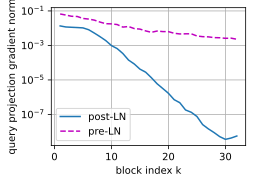

In [3]:
class Stack(nnx.Module):
    def __init__(self, num_blks, pre_norm, num_hiddens=256, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        self.blks = nnx.List([MiniBlock(num_hiddens, pre_norm, rngs)
                              for _ in range(num_blks)])

    def __call__(self, X):
        for blk in self.blks:
            X = blk(X)
        return X

def signal_stats(pre_norm, num_blks=32, num_hiddens=256):
    stack = Stack(num_blks, pre_norm, num_hiddens, rngs=nnx.Rngs(0))
    init, key = nnx.initializers.xavier_uniform(), jax.random.key(0)
    flat = []
    for path, p in nnx.to_flat_state(nnx.state(stack, nnx.Param)):
        if p[...].ndim == 2:           # the 2017 initialization
            key, sub = jax.random.split(key)
            p = jax.tree.map(lambda v: init(sub, v.shape), p)
        flat.append((path, p))
    nnx.update(stack, nnx.from_flat_state(flat))
    X = jax.random.normal(jax.random.key(1), (2, 64, num_hiddens))
    R = jax.random.normal(jax.random.key(2), (2, 64, num_hiddens))
    H, spreads, rms = X, [], []
    for blk in stack.blks:
        H = blk(H)
        spreads.append(float(jnp.linalg.norm(H - H.mean(1, keepdims=True))
                             / jnp.linalg.norm(H)))
        rms.append(float(jnp.sqrt((H ** 2).mean())))
    grads = nnx.grad(lambda m: (m(X) * R).mean())(stack)  # generic readout
    top = grads['blks'][num_blks - 1]['attention']
    proj = {n: float(jnp.linalg.norm(top[n]['kernel'][...]))
            for n in ('W_q', 'W_k', 'W_v', 'W_o')}
    grads = [float(jnp.linalg.norm(
        grads['blks'][k]['attention']['W_q']['kernel'][...]))
        for k in range(num_blks)]
    return spreads, rms, grads, proj

stats = {pre: signal_stats(pre) for pre in (False, True)}
for pre, name in ((False, 'post-LN'), (True, 'pre-LN')):
    spreads, rms, grads, proj = stats[pre]
    print(f'{name:>8}: stream RMS at k=32: {rms[-1]:5.2f},  '
          'token spread at k=8,16,32: '
          + ' '.join(f'{spreads[k-1]:8.1e}' for k in (8, 16, 32)))
    print('          grad norms at k=32: '
          + '  '.join(f'{n} {g:7.1e}' for n, g in proj.items()))
d2l.plot(jnp.arange(1, 33), [stats[False][2], stats[True][2]],
         'block index k', 'query projection gradient norm',
         legend=['post-LN', 'pre-LN'], yscale='log')

The two arrangements produce different networks at the same parameter
values. Post-LN renormalizes the stream after every addition, so its RMS is
pinned at $1$ at every depth; pre-LN only ever adds, so its stream grows
like the square root of the depth (the block outputs are nearly independent
at initialization, and variances add). That growth is not a defect — it is
a protection. Each pre-LN branch reads the stream through its own
normalization, so as the stream grows, each successive block's *relative*
contribution shrinks, and the function stays tame.

The post-LN stack has no such damping, and the token-spread column shows
what happens instead. At initialization attention is nearly uniform, so
every attention sublayer pulls each token toward the average token; post-LN
then renormalizes, locking in the contraction, and the spread decays
*geometrically* — by block 32 the tokens are identical to about one part in
ten thousand. Pre-LN dilutes the same contraction by the growing stream,
and the spread falls only polynomially, still at $0.4$ after 32 blocks.
This is the *rank collapse* of @Dong.Cordonnier.Loukas.2021 caught
in the act, and the gradients show why it matters for learning: a head
attending over identical tokens returns the same mixture *whatever its
query and key weights*, so those weights stop receiving gradient. The
block-32 norms printed above locate the starvation precisely: post-LN's
query and key projections receive gradients of order $10^{-9}$, six
orders of magnitude below their pre-LN counterparts, while its value and
output projections — which transform the one surviving token rather than
compare tokens — come in around $0.06$, as healthy as pre-LN's (the FFN
parameters, fed by the same residual stream, are likewise unaffected). It
is specifically the query/key pathway, the part that decides *where* to
attend, that dies; the plot shows the same starvation deepening block by
block down the post-LN stack, while pre-LN tapers gently. (The effect
softens under today's smaller initializations — one of several crutches,
along with learning-rate warmup, that kept deep post-LN models trainable
[@xiong2020layer].)

The practical verdict matched this picture: post-LN transformers diverge
without carefully tuned warmup, pre-LN models train without incident at the
same depth [@xiong2020layer], and essentially every model since GPT-2
has been pre-norm [@Radford.Wu.Child.ea.2019]. We make pre-norm our
default; the next section, which has a trainable model, will show the
post-LN failure not at initialization but live, during training.

### RMSNorm

Modern models also simplified the normalizer itself. LayerNorm standardizes
each token vector by subtracting its mean and dividing by its standard
deviation, then rescales (and re-shifts) feature-wise. *RMSNorm*
[@Zhang.Sennrich.2019] drops the centering and the shift, keeping only
the part that controls scale:

$$
\mathrm{RMSNorm}(\mathbf{x}) = \frac{\mathbf{x}}{\sqrt{\tfrac{1}{d} \sum_{i=1}^{d} x_i^2 + \epsilon}} \odot \boldsymbol{\gamma}.
$$

It is a one-line function, and both frameworks ship it; let's verify our
implementation against the built-in and time the two normalizers.

In [4]:
def rms_norm(X, weight, eps=1e-6):
    return X / jnp.sqrt((X * X).mean(-1, keepdims=True) + eps) * weight

X = jax.random.normal(jax.random.key(0), (64, 512, 1024))
layernorm = nnx.LayerNorm(1024, rngs=nnx.Rngs(0))
rmsnorm = nnx.RMSNorm(1024, epsilon=1e-6, rngs=nnx.Rngs(0))
print(f'ours vs. built-in: max deviation '
      f'{jnp.abs(rms_norm(X, rmsnorm.scale[...]) - rmsnorm(X)).max():.1e}')
for name, f in (('LayerNorm', nnx.jit(layernorm)),
                ('RMSNorm', nnx.jit(rmsnorm))):
    f(X).block_until_ready()       # warmup + compile
    t0 = time.time()
    for _ in range(200):
        Y = f(X)
    Y.block_until_ready()
    print(f'{name}: {(time.time() - t0) / 200 * 1e3:.3f} ms')

ours vs. built-in: max deviation 9.5e-07


LayerNorm: 1.076 ms


RMSNorm: 0.732 ms


The timing is close to an anticlimax: on a modern GPU both normalizers are
memory-bound, and what dropping the mean subtraction saves depends on the
framework's kernel — nothing measurable in our PyTorch run, roughly a third
in our JAX run, and either way microseconds in blocks that spend their time
elsewhere. What RMSNorm actually buys is less machinery — no centering, no
bias parameter, one statistic instead of two — at comparable quality, which
is why Llama and most open models since use it [@touvron2023llama]. The
lesson is about defaults rather than speed: when a component's job is "keep
the scale near one", the simplest layer that does the job wins.

### Normalizing Queries and Keys

One more normalization migrated *inside* attention. Nothing in the block
above controls the size of the attention logits
$\mathbf{q}^\top \mathbf{k} / \sqrt{d}$ themselves: if training inflates
the queries and keys, the softmax saturates, its Jacobian vanishes
(that section), and training can spike or
stall — an instability first met at vision-transformer scale, where
attention entropy was observed collapsing in billion-parameter runs
[@Dehghani.Djolonga.Mustafa.ea.2023]. *QK-norm*
[@Henry.Dachapally.Pawar.ea.2020] applies RMSNorm to the queries and
keys per head, right before the dot product, so the logit scale is pinned
by construction rather than by hope. It costs two extra norms per layer and
has become a standard ingredient of 2025-era models (Gemma 3, Qwen3, and
OLMo 2 all ship it). OLMo 2 is also the one prominent re-litigation of this
section's verdict: it pairs QK-norm with norms placed *after* each sublayer
— though still off the stream's identity path, conceding the main lesson of
the experiment above [@OLMo.2025]. Gemma 3 hedges in the other
direction and normalizes each branch on both sides, before *and* after the
sublayer [@Gemma.Team.2025]. the figure lays the four
placements now in circulation side by side; note that only the original
post-LN interrupts the stream itself, which is why it alone collapses in
the experiment above. We leave QK-norm as an exercise rather than a flag;
it drops into the block through the `attn_factory` hook introduced below.

![Four placements of normalization around one sublayer; the FFN sublayer is treated identically, and the residual stream runs bottom to top. Post-LN normalizes the stream itself after each addition; pre-LN normalizes what the branch reads; OLMo 2 normalizes what the branch writes; Gemma 3 normalizes the branch on both sides. Only post-LN touches the stream's identity path.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-transformers-norm-taxonomy.svg)

## The Feed-Forward Network

Between the attention sublayers sits the block's other half: a small MLP
applied to each position independently,

$$
\mathrm{FFN}(\mathbf{x}) = \mathbf{W}_2\, \phi(\mathbf{W}_1 \mathbf{x}),
$$

with $\mathbf{W}_1 \in \mathbb{R}^{4d \times d}$ and $\mathbf{W}_2 \in
\mathbb{R}^{d \times 4d}$ in the classic configuration. The factor-4
expansion is a convention the field has never found strong reason to
revisit; what it implies is worth noticing: the FFN holds $8d^2$ parameters
against attention's $4d^2$, so about two thirds of a block's parameters sit
in these two matrices. When people say a transformer's knowledge lives
mostly in its FFNs, this ratio is the accounting behind the claim.

Two upgrades separate the 2017 FFN from today's. The activation $\phi$
moved from ReLU to *GELU* [@Hendrycks.Gimpel.2016], a smoothed relative
that ends the debate about the kink at zero (GPT onward
[@Radford.Narasimhan.Salimans.ea.2018]). Then @Shazeer.2020
revived an older idea — gating — and found that a *gated linear unit* with
the SiLU activation beat both:

$$
\mathrm{SwiGLU}(\mathbf{x}) = \mathbf{W}_2 \big(\mathrm{SiLU}(\mathbf{W}_g \mathbf{x}) \odot \mathbf{W}_1 \mathbf{x}\big), \qquad \mathrm{SiLU}(z) = z \cdot \mathrm{sigmoid}(z).
$$

Instead of gating a linear transform through a fixed nonlinearity, SwiGLU
computes *two* linear views of the input and multiplies them, one squashed
into a soft gate, the other passed through untouched — the value is
transmitted at full strength wherever the gate is open, rather than bent
through the activation. The multiplicative interaction is the same trick
gates played in LSTMs, here compressed into a single layer. A third matrix
means more parameters at the same width, so fair comparisons shrink the
hidden width to $\tfrac{8}{3} d$, making three matrices of the gated FFN
cost the same $8d^2$ as the classic one, up to rounding. Both variants, in
one class:

In [5]:
class FeedForward(nnx.Module):
    """Position-wise FFN: GELU MLP or SwiGLU at matched parameter count."""
    def __init__(self, num_hiddens, act='swiglu', bias=False, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        assert act in ('swiglu', 'gelu'), f'unknown act: {act!r}'
        self.act = act
        if act == 'gelu':
            width = 4 * num_hiddens
        else:  # 'swiglu': three matrices; width 8d/3 matches the MLP budget
            width = round(8 * num_hiddens / 3)
            self.W_g = nnx.Linear(num_hiddens, width, use_bias=bias,
                                  rngs=rngs)
        self.W_1 = nnx.Linear(num_hiddens, width, use_bias=bias, rngs=rngs)
        self.W_2 = nnx.Linear(width, num_hiddens, use_bias=bias, rngs=rngs)

    def __call__(self, X):
        if self.act == 'gelu':
            return self.W_2(nnx.gelu(self.W_1(X)))
        return self.W_2(nnx.silu(self.W_g(X)) * self.W_1(X))

(The GELU here is the tanh approximation, the exact variant GPT-2 shipped
with — a detail that will matter when we load its weights in
that section.) The parameter match is worth checking rather than
trusting:

In [6]:
for act in ('gelu', 'swiglu'):
    ffn = FeedForward(256, act)
    n = sum(p.size for p in jax.tree.leaves(nnx.state(ffn, nnx.Param)))
    print(f'{act:>7}: {n} parameters')

   gelu: 524288 parameters


 swiglu: 524544 parameters


Whether the gate is *worth* anything at equal cost is an empirical
question, and a matched-budget race settles it — but only once we have a
model to train. That is the closing experiment of this section.

## A Configurable Block

We now assemble the block for real, and we build it the way this chapter
will use it: every design decision above becomes a constructor argument.
`norm` selects LayerNorm or RMSNorm, `act` selects the FFN, `pre_norm`
selects the arrangement, and two factory hooks let later sections swap
whole sublayers — a mixture-of-experts FFN, or a cache-friendly
grouped-query attention — without touching this class again. The
constructor validates its flag strings: a typo must fail loudly, not
silently select an architecture. The default configuration (pre-norm,
RMSNorm, SwiGLU) is the one you would find inside an open-weights model
released this year; `TransformerBlock(num_hiddens, num_heads, norm='layer',
act='gelu', pre_norm=False, bias=True)` is a compact post-norm block in the
2017 encoder arrangement (with one anachronism kept for simplicity: GELU,
where the 2017 original used ReLU).

In [7]:
class TransformerBlock(nnx.Module):
    """Configurable transformer block: attention + FFN on a residual
    stream."""
    def __init__(self, num_hiddens, num_heads, dropout=0, norm='rms',
                 act='swiglu', pre_norm=True, bias=False, attn_factory=None,
                 ffn_factory=None, rngs=None):
        rngs = nnx.Rngs(params=0, dropout=1) if rngs is None else rngs
        assert norm in ('rms', 'layer'), f'unknown norm: {norm!r}'
        assert num_hiddens % num_heads == 0
        self.pre_norm = pre_norm
        make_norm = nnx.RMSNorm if norm == 'rms' else nnx.LayerNorm
        self.norm1 = make_norm(num_hiddens, rngs=rngs)
        self.norm2 = make_norm(num_hiddens, rngs=rngs)
        self.attention = (d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                 dropout, bias=bias,
                                                 rngs=rngs)
                          if attn_factory is None else attn_factory(rngs))
        self.ffn = (FeedForward(num_hiddens, act, bias=bias, rngs=rngs)
                    if ffn_factory is None else ffn_factory(rngs))
        self.dropout = nnx.Dropout(dropout, rngs=rngs)

    def __call__(self, X, valid_lens=None):
        if self.pre_norm:
            Y = self.norm1(X)
            X = X + self.dropout(self.attention(Y, Y, Y, valid_lens)[0])
            return X + self.dropout(self.ffn(self.norm2(X)))
        X = self.norm1(X + self.dropout(
            self.attention(X, X, X, valid_lens)[0]))
        return self.norm2(X + self.dropout(self.ffn(X)))

### Shapes and Parameters

The block preserves its input shape whatever the flags, and its parameter
census confirms the accounting from above: $4d^2$ in attention, $8d^2$ in
the FFN (however the activation slices it), and a rounding error of
normalization weights — about $12d^2$ per block, two thirds of it FFN.

In [8]:
X = jnp.ones((2, 10, 256))
blk = TransformerBlock(256, num_heads=8)
blk2017 = TransformerBlock(256, num_heads=8, norm='layer', act='gelu',
                           pre_norm=False, bias=True)
d2l.check_shape(blk(X), X.shape)
d2l.check_shape(blk2017(X), X.shape)
count = lambda m: sum(p.size for p in jax.tree.leaves(
    nnx.state(m, nnx.Param)))
print(f'attention {count(blk.attention)}, ffn {count(blk.ffn)}, '
      f'total {count(blk)} = {count(blk) / 256 ** 2:.2f} d^2')

attention 262144, ffn 524544, total 787200 = 12.01 d^2


One block is not yet a language model, but it is close enough to train.
The same `valid_lens` mechanism that masked padding in
that section makes the block *causal*: pass
each query a valid length equal to its own position, and every token
attends only backward. A dozen lines wrap an embedding, a stack of blocks,
and a tied output head (as in that section) around
that trick:

In [9]:
class CharLM(nnx.Module):
    """Minimal char LM: causal masking via per-query valid lengths."""
    def __init__(self, vocab_size, num_hiddens=128, num_heads=4, num_blks=2,
                 act='swiglu', max_len=128, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        init = nnx.initializers.normal(0.02)
        self.token_emb = nnx.Embed(vocab_size, num_hiddens,
                                   embedding_init=init, rngs=rngs)
        self.pos_emb = nnx.Embed(max_len, num_hiddens,
                                 embedding_init=init, rngs=rngs)
        self.blks = nnx.List([
            TransformerBlock(num_hiddens, num_heads, act=act, rngs=rngs)
            for _ in range(num_blks)])
        self.norm = nnx.RMSNorm(num_hiddens, rngs=rngs)

    def __call__(self, X):
        B, T = X.shape
        H = self.token_emb(X) + self.pos_emb(jnp.arange(T))
        causal = jnp.tile(jnp.arange(1, T + 1), (B, 1))
        for blk in self.blks:
            H = blk(H, causal)
        return self.token_emb.attend(self.norm(H))

### The Flags at Work: GELU versus SwiGLU

Now the promised race. Same data (the character-level Time Machine corpus
of that section), same model, same seed, same optimizer and
learning rate, same 600 steps — the only difference is the `act` flag, and
the parameter counts match to a tenth of a percent.

In [10]:
data = d2l.TimeMachine(batch_size=64, num_steps=128, tokenization='char',
                       num_train=100000, num_val=3000)
for act in ('gelu', 'swiglu'):
    model = CharLM(len(data.vocab), act=act, rngs=nnx.Rngs(0))
    optimizer = nnx.Optimizer(model, optax.adamw(1e-3, weight_decay=0.0),
                              wrt=nnx.Param)
    losses = d2l.train_lm(model, data, optimizer, 600)
    print(f'{act:>7}: loss at step 200/400/600: ' + '/'.join(
        f'{sum(losses[k-100:k]) / 100:.2f}' for k in (200, 400, 600)))

   gelu: loss at step 200/400/600: 2.27/1.73/1.41


 swiglu: loss at step 200/400/600: 2.22/1.57/1.24


The gated FFN ends more than a tenth of a nat ahead — a margin that holds up
across seeds (rerunning with seeds 1 and 2 moves each number by a couple of
hundredths, not the gap) and, more importantly, agrees in direction with
@Shazeer.2020's systematic sweep and with the consistent choice of
the major model families since Llama. It is a modest, real improvement of
the kind that architecture progress is actually made of: no single dramatic
win, but a percent here and a percent there, at equal cost, compounding.

## Summary

A transformer block is two sublayers writing into a residual stream:
attention communicates between positions, the position-wise FFN computes
within each one and holds about two thirds of the parameters. Where the
normalization goes decides how deep stacks behave at initialization: the
post-LN arrangement of 2017 renormalizes the stream after each addition,
which pins its scale but lets near-uniform attention collapse the tokens
geometrically — the query and key projections at the top of a 32-block
stack receive gradients six orders of magnitude smaller than at the
bottom, while the value, output, and FFN weights keep ordinary gradients;
it is the where-to-attend pathway that starves.
Pre-norm moves the normalizer onto each branch, lets the stream grow like
the square root of the depth, and keeps every block trainable; it has been
the default since GPT-2. RMSNorm keeps only the scale statistic (same
measured cost, less machinery), and QK-norm extends the same discipline to
the attention logits. In the FFN, SwiGLU replaces the fixed nonlinearity
with a learned soft gate; at matched parameter count it wins by a small,
seed-stable margin on our character model, consistent with its
near-universal adoption. The section's product is `TransformerBlock`:
normalization,
activation, and arrangement as flags, attention and FFN as swappable
factories — the single unit from which this chapter builds a GPT, a
KV-cached decoder, an encoder, a vision transformer, and a
mixture-of-experts model.

## Exercises

1. At initialization the block outputs are nearly independent, so the
   pre-norm stream RMS should grow like $\sqrt{1 + 2N}$ after $N$ blocks
   with two sublayers each — up to the sublayers' output scale. Extend the
   signal-propagation experiment to fit the growth exponent from a log-log
   plot. How close is it to $1/2$, and why does the attention sublayer
   contribute less than the FFN sublayer early in the stack?
2. OLMo 2 places the normalization *after* each sublayer but *off* the
   stream: $\mathbf{h} = \mathbf{x} +
   \mathrm{Norm}(\mathrm{Attn}(\mathbf{x}))$. Add this third arrangement to
   `MiniBlock` and rerun the experiment. Which of post-LN's pathologies
   does it avoid, which of pre-LN's properties does it give up, and what
   happens to the stream RMS?
3. The signal-propagation experiment uses the 2017 Xavier initialization.
   Rerun it with each framework's default initialization and with all
   weights scaled by an extra factor of $0.5$. How does the collapse depth
   change? Relate your observations to why post-LN models of GPT-1's era
   (12 blocks) were trainable at all.
4. Implement two more of @Shazeer.2020's gated variants by changing
   one line of `FeedForward`: ReGLU (ReLU gate) and GEGLU (GELU gate). Race
   all four at matched parameters on `CharLM`. Do your rankings agree with
   the paper's? What does the spread between the gated variants, compared
   with the gap to the ungated MLP, tell you about *which* design choice
   carries the improvement?
5. Work out the exact parameter count of `TransformerBlock(d, h)` for both
   `act` settings, including normalization weights, and check it against
   the census cell. Real models round the SwiGLU width up to a multiple of
   256 for hardware efficiency; how far from $8d^2$ does the Llama-7B
   configuration ($d = 4096$, FFN width $11008$) land?
6. Implement QK-norm as an `attn_factory`: wrap `d2l.MultiHeadAttention`
   so that queries and keys pass through an RMSNorm (one per head
   dimension) before the dot product. At initialization, measure the
   standard deviation of the attention logits with and without it as you
   scale `num_hiddens` from 64 to 1024. Which curve does
   the equation's $1/\sqrt{d}$ scaling predict, and
   which do you observe?